In [3]:
import pandas as pd
import numpy as np
import time
from xgboost import XGBClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import classification_report, f1_score, hamming_loss, accuracy_score
from sklearn.model_selection import train_test_split
from pathlib import Path
import mlflow

# Import PySwarms untuk Binary PSO
import pyswarms as ps

# ==========================================
# 0. MLFLOW SETUP
# ==========================================
root_path = Path.cwd().parent
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path=root_path / ".env") # Load variabel dari .env
# Gunakan DagsHub URI jika ada di .env, jika tidak pakai folder lokal mlruns
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", (root_path / "mlruns").as_uri())
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("07f_Baseline_BPSO_XGBoost")

# ==========================================
# 1. LOAD DATA
# ==========================================
print("🔍 1. Memuat dataset untuk BPSO...")
train_balanced = pd.read_csv(root_path / "Data/processed/train_balanced_multilabel.csv")
train_ori = pd.read_csv(root_path / "Data/split/train_data.csv")
test_data = pd.read_csv(root_path / "Data/split/test_data.csv")

target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']

# Pisahkan X dan y — SMOTE (untuk training utama)
X_train_df = train_balanced.drop(columns=target_cols)
y_train_df = train_balanced[target_cols].astype(int)

# Data asli (untuk kalibrasi threshold)
X_train_ori_df = train_ori.drop(columns=target_cols)
y_train_ori_df = train_ori[target_cols].astype(int)

# Samakan kolom data asli mengikuti train SMOTE
X_train_ori_df = X_train_ori_df.reindex(columns=X_train_df.columns, fill_value=0)

# Test data
X_test_df = test_data.drop(columns=target_cols)
y_test_df = test_data[target_cols].astype(int)
X_test_df = X_test_df.reindex(columns=X_train_df.columns, fill_value=0)

# Konversi ke Numpy Array (syarat BPSO)
feature_names = X_train_df.columns
X_train = X_train_df.values
y_train = y_train_df.values
X_train_ori = X_train_ori_df.values
y_train_ori = y_train_ori_df.values
X_test = X_test_df.values
y_test = y_test_df.values

num_features = X_train.shape[1]
print(f"✓ Jumlah fitur awal: {num_features} fitur")
print(f"✓ Data Train SMOTE shape: {X_train.shape}")
print(f"✓ Data Train Asli shape : {X_train_ori.shape}")
print(f"✓ Data Test shape       : {X_test.shape}")

# Split data ASLI → Train_sub + Validation (untuk kalibrasi threshold)
print("\n🔀 Split Data Asli → Train_sub & Validation (80-20) untuk kalibrasi threshold...")
X_train_sub_ori, X_val_ori, y_train_sub_ori, y_val_ori = train_test_split(
    X_train_ori, y_train_ori, test_size=0.2, random_state=42
)
print(f"   ✓ Train sub (asli) : {X_train_sub_ori.shape}")
print(f"   ✓ Validation (asli): {X_val_ori.shape}")

# ==========================================
# 2. STANDARDIZED XGBOOST PARAMETERS
# ==========================================
xgb_params_final = {
  "n_estimators": 100,
  "max_depth": 5,
  "learning_rate": 0.0833,
  "gamma": 0,
  "colsample_bytree": 0.5667,
  "subsample": 0.8333,
  "min_child_weight": 3,
  "eval_metric": "logloss",
  "random_state": 42,
  "n_jobs": -1
}

xgb_params_fitness = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'random_state': 42,
    'eval_metric': 'logloss',
    'n_jobs': -1
}

print("\n🔧 2. XGBoost Parameters untuk Standardized Benchmarking:")
print(f"   Final Training: n_est={xgb_params_final['n_estimators']}, lr={xgb_params_final['learning_rate']}, depth={xgb_params_final['max_depth']}")
print(f"   Fitness Phase: n_est={xgb_params_fitness['n_estimators']}, lr={xgb_params_fitness['learning_rate']} (lightweight)")

# ==========================================
# 3. DEFINISI FUNGSI FITNESS (EVALUASI PARTIKEL)
# ==========================================
base_xgb_fitness = XGBClassifier(**xgb_params_fitness)
chain_model_fitness = ClassifierChain(base_xgb_fitness, order='random', random_state=42)

def f_per_particle(m, alpha=0.01):
    if np.count_nonzero(m) == 0:
        return 1.0
    X_subset = X_train[:, m == 1]
    chain_model_fitness.fit(X_subset, y_train)
    preds = chain_model_fitness.predict(X_subset)
    f1 = f1_score(y_train, preds, average='macro')
    cost = (1.0 - f1) + (alpha * (np.count_nonzero(m) / num_features))
    return cost

def fitness_function(x):
    n_particles = x.shape[0]
    j = [f_per_particle(x[i]) for i in range(n_particles)]
    return np.array(j)

# ==========================================
# 4. KONFIGURASI DAN EKSEKUSI BPSO
# ==========================================
print("\n⏳ 3. Memulai proses seleksi fitur BPSO (Feature Optimization)...")
options = {'c1': 0.5, 'c2': 0.5, 'w': 0.9, 'k': 30, 'p': 2}

optimizer = ps.discrete.binary.BinaryPSO(n_particles=30, dimensions=num_features, options=options)

bpso_start_time = time.time()
cost, pos = optimizer.optimize(fitness_function, iters=20)
bpso_time = time.time() - bpso_start_time
print(f"   ✓ BPSO Feature Selection selesai dalam {bpso_time:.2f} detik.")

# ==========================================
# 5. EVALUASI HASIL BPSO
# ==========================================
selected_features_indices = np.where(pos == 1)[0]
selected_features_names = feature_names[selected_features_indices]

num_selected_features = len(selected_features_indices)
print(f"   ✓ Fitur terpilih BPSO: {num_selected_features} fitur (dari {num_features})")
print(f"   ✓ Reduction ratio: {(1 - num_selected_features/num_features)*100:.1f}%")

# Ambil subset fitur terpilih
X_train_bpso = X_train[:, selected_features_indices]
X_test_bpso  = X_test[:, selected_features_indices]

# ==========================================
# 6. HELPER FUNCTIONS
# ==========================================
def find_optimal_thresholds_bpso(model, X_data, y_data, targets, step=0.01):
    """Mencari threshold optimal per target class menggunakan data validasi ASLI."""
    n_samples  = X_data.shape[0]
    n_targets  = len(targets)
    all_probas = np.zeros((n_samples, n_targets))

    X_aug = X_data.copy()
    for i, estimator in enumerate(model.estimators_):
        proba = estimator.predict_proba(X_aug)[:, 1]
        all_probas[:, i] = proba
        pred_label = (proba >= 0.5).astype(int).reshape(-1, 1)
        X_aug = np.hstack([X_aug, pred_label])

    best_thresholds = []
    print(f"\n   {'Target':<20} {'Threshold':>10} {'Val F1':>10}")
    print(f"   {'-'*42}")

    for i, target_name in enumerate(targets):
        best_t  = 0.5
        best_f1 = 0.0
        for t in np.arange(0.1, 0.9, step):
            y_pred_temp = (all_probas[:, i] >= t).astype(int)
            f1 = f1_score(y_data[:, i], y_pred_temp, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t  = t
        best_thresholds.append(round(best_t, 2))
        print(f"   {target_name:<20} {best_t:>10.2f} {best_f1:>10.4f}")

    return best_thresholds


def apply_thresholds_bpso(model, X_data, thresholds, targets):
    """Menerapkan threshold kustom ke prediksi test data."""
    n_samples  = X_data.shape[0]
    n_targets  = len(targets)
    all_probas = np.zeros((n_samples, n_targets))

    X_aug = X_data.copy()
    for i, estimator in enumerate(model.estimators_):
        proba = estimator.predict_proba(X_aug)[:, 1]
        all_probas[:, i] = proba
        pred_label = (proba >= thresholds[i]).astype(int).reshape(-1, 1)
        X_aug = np.hstack([X_aug, pred_label])

    y_pred_optimized = np.zeros((n_samples, n_targets), dtype=int)
    for i in range(n_targets):
        y_pred_optimized[:, i] = (all_probas[:, i] >= thresholds[i]).astype(int)

    return y_pred_optimized


def evaluate_predictions(y_true, y_pred, label=""):
    """Hitung semua metrik evaluasi."""
    macro_f1    = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1    = f1_score(y_true, y_pred, average='micro', zero_division=0)
    hamming     = hamming_loss(y_true, y_pred)
    exact_match = accuracy_score(y_true, y_pred)
    return {
        "label":        label,
        "Macro_F1":     macro_f1,
        "Micro_F1":     micro_f1,
        "Hamming_Loss": hamming,
        "Exact_Match":  exact_match,
    }

# ==========================================
# 7. TRAINING MODEL UTAMA (Data SMOTE + fitur BPSO)
# ==========================================
print("\n🔨 4. Training MODEL UTAMA dengan fitur BPSO di data SMOTE...")
final_xgb   = XGBClassifier(**xgb_params_final)
final_chain  = ClassifierChain(final_xgb, order='random', random_state=42)

final_start_time = time.time()
final_chain.fit(X_train_bpso, y_train)
final_train_time = time.time() - final_start_time
print(f"   ✓ Model utama selesai dalam {final_train_time:.2f} detik.")

# ==========================================
# 8. TRAINING MODEL SEMENTARA (Data Asli + fitur BPSO, untuk kalibrasi threshold)
# ==========================================
print("\n🔧 5. Training model sementara di 80% data asli untuk kalibrasi threshold...")
X_train_sub_ori_bpso = X_train_sub_ori[:, selected_features_indices]
X_val_ori_bpso = X_val_ori[:, selected_features_indices]

temp_xgb = XGBClassifier(**xgb_params_final)
temp_chain = ClassifierChain(temp_xgb, order='random', random_state=42)
temp_chain.fit(X_train_sub_ori_bpso, y_train_sub_ori)
print("   ✓ Model sementara selesai dilatih")

# ==========================================
# 9. EVALUASI DEFAULT (THRESHOLD 0.5)
# ==========================================
print("\n📊 6. Prediksi dengan threshold default (0.5)...")
y_pred_default = final_chain.predict(X_test_bpso)
results_default = evaluate_predictions(y_test, y_pred_default, "Default (0.5)")

total_time = bpso_time + final_train_time

print("\n" + "="*70)
print("🏆 HASIL BASELINE: XGBOOST + BPSO FEATURE SELECTION (Default)")
print("="*70)
print(f"Jumlah Fitur (Original):       {num_features}")
print(f"Jumlah Fitur (BPSO Selected):  {num_selected_features}")
print(f"Feature Reduction:             {(1 - num_selected_features/num_features)*100:.1f}%")
print(f"\nMacro F1-Score:                {results_default['Macro_F1']:.4f}")
print(f"Micro F1-Score:                {results_default['Micro_F1']:.4f}")
print(f"Hamming Loss:                  {results_default['Hamming_Loss']:.4f}")
print(f"Exact Match Accuracy:          {results_default['Exact_Match']:.4f}")
print(f"\nBPSO Optimization Time:        {bpso_time:.2f} detik")
print(f"Final Training Time:           {final_train_time:.2f} detik")
print(f"Total Execution Time:          {total_time:.2f} detik")
print("="*70)

print("\n📋 DETAIL CLASSIFICATION REPORT (Default Threshold):")
print(classification_report(y_test, y_pred_default, target_names=['Depression', 'Anxiety', 'Stress']))

# ==========================================
# 10. THRESHOLD OPTIMIZATION (dari model sementara + data validasi ASLI)
# ==========================================
print("\n" + "="*70)
print("🔍 THRESHOLD OPTIMIZATION (Kalibrasi Data Asli)")
print("="*70)

print("\n🔍 Mencari threshold optimal dari data validasi ASLI...")
optimal_thresholds = find_optimal_thresholds_bpso(
    temp_chain, X_val_ori_bpso, y_val_ori, target_cols
)
print(f"\n   Threshold optimal: {dict(zip(target_cols, optimal_thresholds))}")

# Buang model sementara
del temp_chain, temp_xgb
print("   ✓ Model sementara dibuang")

# ==========================================
# 11. EVALUASI DENGAN THRESHOLD OPTIMAL (pakai model UTAMA)
# ==========================================
print("\n📊 7. Prediksi dengan threshold optimal (model utama)...")
y_pred_optimized = apply_thresholds_bpso(
    final_chain, X_test_bpso, optimal_thresholds, target_cols
)
results_optimized = evaluate_predictions(y_test, y_pred_optimized, "Optimized")

# ==========================================
# 12. TAMPILKAN HASIL PERBANDINGAN
# ==========================================
print("\n" + "="*70)
print("📊 PERBANDINGAN DEFAULT vs THRESHOLD OPTIMIZED")
print("="*70)
print(f"{'Metrik':<25} {'Default (0.5)':>15} {'Optimized':>15} {'Δ':>10}")
print("-"*70)

for metric in ['Macro_F1', 'Micro_F1', 'Hamming_Loss', 'Exact_Match']:
    val_def  = results_default[metric]
    val_opt  = results_optimized[metric]
    delta    = val_opt - val_def
    arrow    = "↑" if delta > 0 else ("↓" if delta < 0 else "→")
    print(f"{metric:<25} {val_def:>15.4f} {val_opt:>15.4f} {arrow} {delta:>+.4f}")
print("="*70)

print(f"\nThreshold Optimal (kalibrasi data asli):")
for col, t in zip(target_cols, optimal_thresholds):
    print(f"   {col:<25}: {t:.2f}")

print("\n📋 DETAIL CLASSIFICATION REPORT (Threshold Optimized):")
print(classification_report(
    y_test, y_pred_optimized,
    target_names=['Depression', 'Anxiety', 'Stress']
))

# ==========================================
# 13. MLFLOW TRACKING
# ==========================================
print("\n📈 8. Tracking ke MLflow...")
with mlflow.start_run(run_name="XGBoost_BPSO_ThresholdKalibrasiAsli"):
    # Log BPSO parameters
    mlflow.log_param("feature_selection_method", "Binary PSO (BPSO)")
    mlflow.log_param("threshold_calibration", "Data Asli (80-20 split)")
    mlflow.log_param("bpso_n_particles", 30)
    mlflow.log_param("bpso_iterations", 20)
    mlflow.log_param("bpso_options_c1", 0.5)
    mlflow.log_param("bpso_options_c2", 0.5)
    mlflow.log_param("bpso_options_w", 0.9)

    # Log Final XGBoost parameters
    for param_name, param_value in xgb_params_final.items():
        mlflow.log_param(f"final_xgb_{param_name}", param_value)

    # Log Fitness XGBoost parameters
    for param_name, param_value in xgb_params_fitness.items():
        mlflow.log_param(f"fitness_xgb_{param_name}", param_value)

    # Log feature info
    mlflow.log_param("multilabel_strategy", "ClassifierChain")
    mlflow.log_param("num_original_features", num_features)
    mlflow.log_param("num_selected_features", num_selected_features)
    mlflow.log_param("feature_reduction_percentage",
                     f"{(1 - num_selected_features/num_features)*100:.1f}")

    # Metrik default
    mlflow.log_metric("Default_Macro_F1",     results_default['Macro_F1'])
    mlflow.log_metric("Default_Micro_F1",     results_default['Micro_F1'])
    mlflow.log_metric("Default_Hamming_Loss", results_default['Hamming_Loss'])
    mlflow.log_metric("Default_Exact_Match",  results_default['Exact_Match'])

    # Metrik threshold optimized
    mlflow.log_metric("Optimized_Macro_F1",     results_optimized['Macro_F1'])
    mlflow.log_metric("Optimized_Micro_F1",     results_optimized['Micro_F1'])
    mlflow.log_metric("Optimized_Hamming_Loss", results_optimized['Hamming_Loss'])
    mlflow.log_metric("Optimized_Exact_Match",  results_optimized['Exact_Match'])

    # Threshold optimal per target
    for col, t in zip(target_cols, optimal_thresholds):
        mlflow.log_metric(f"Threshold_{col}", t)

    mlflow.log_metric("BPSO_Time_seconds",          bpso_time)
    mlflow.log_metric("Final_Training_Time_seconds", final_train_time)
    mlflow.log_metric("Total_Time_seconds",          total_time)

    # Log selected features
    mlflow.log_dict({
        "selected_features":        selected_features_names.tolist(),
        "selected_feature_indices": selected_features_indices.tolist()
    }, "bpso_selected_features.json")

    # Log threshold optimal
    mlflow.log_dict(
        {"optimal_thresholds": dict(zip(target_cols, optimal_thresholds))},
        "07f_optimal_thresholds.json"
    )

    print("   ✓ MLflow tracking selesai!")

print(f"\n📌 CATATAN PENTING:")
print(f"   - Model UTAMA dilatih di data SMOTE ({X_train_bpso.shape[0]} sampel)")
print(f"   - Threshold dikalibrasi di data ASLI (validasi split 20%)")
print(f"   - BPSO mengurangi fitur dari {num_features} → {num_selected_features} ({(1 - num_selected_features/num_features)*100:.1f}% reduction)")
print(f"   - Lihat 07d (MFO), 07e (All Features), 07g (GA) untuk perbandingan")

print("\n✅ Notebook eksekusi SELESAI!")


🔍 1. Memuat dataset untuk BPSO...


2026-05-14 19:58:22,890 - pyswarms.discrete.binary - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.5, 'w': 0.9, 'k': 30, 'p': 2}


✓ Jumlah fitur awal: 37 fitur
✓ Data Train SMOTE shape: (8724, 37)
✓ Data Train Asli shape : (21740, 37)
✓ Data Test shape       : (5436, 37)

🔀 Split Data Asli → Train_sub & Validation (80-20) untuk kalibrasi threshold...
   ✓ Train sub (asli) : (17392, 37)
   ✓ Validation (asli): (4348, 37)

🔧 2. XGBoost Parameters untuk Standardized Benchmarking:
   Final Training: n_est=100, lr=0.0833, depth=5
   Fitness Phase: n_est=100, lr=0.1 (lightweight)

⏳ 3. Memulai proses seleksi fitur BPSO (Feature Optimization)...


pyswarms.discrete.binary: 100%|██████████|20/20, best_cost=0.239
2026-05-14 20:00:43,300 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.23908423136085316, best pos: [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 0 1 1 1 1 0 1 0 1 1]


   ✓ BPSO Feature Selection selesai dalam 140.41 detik.
   ✓ Fitur terpilih BPSO: 24 fitur (dari 37)
   ✓ Reduction ratio: 35.1%

🔨 4. Training MODEL UTAMA dengan fitur BPSO di data SMOTE...
   ✓ Model utama selesai dalam 0.35 detik.

🔧 5. Training model sementara di 80% data asli untuk kalibrasi threshold...
   ✓ Model sementara selesai dilatih

📊 6. Prediksi dengan threshold default (0.5)...

🏆 HASIL BASELINE: XGBOOST + BPSO FEATURE SELECTION (Default)
Jumlah Fitur (Original):       37
Jumlah Fitur (BPSO Selected):  24
Feature Reduction:             35.1%

Macro F1-Score:                0.7842
Micro F1-Score:                0.7840
Hamming Loss:                  0.2721
Exact Match Accuracy:          0.5611

BPSO Optimization Time:        140.41 detik
Final Training Time:           0.35 detik
Total Execution Time:          140.76 detik

📋 DETAIL CLASSIFICATION REPORT (Default Threshold):
              precision    recall  f1-score   support

  Depression       0.87      0.71      0.78 

d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

   risk_depression            0.39     0.8644
   risk_anxiety               0.33     0.8681
   risk_stress                0.65     0.8282

   Threshold optimal: {'risk_depression': np.float64(0.39), 'risk_anxiety': np.float64(0.33), 'risk_stress': np.float64(0.65)}
   ✓ Model sementara dibuang

📊 7. Prediksi dengan threshold optimal (model utama)...

📊 PERBANDINGAN DEFAULT vs THRESHOLD OPTIMIZED
Metrik                      Default (0.5)       Optimized          Δ
----------------------------------------------------------------------
Macro_F1                           0.7842          0.8111 ↑ +0.0269
Micro_F1                           0.7840          0.8113 ↑ +0.0273
Hamming_Loss                       0.2721          0.2496 ↓ -0.0224
Exact_Match                        0.5611          0.5762 ↑ +0.0151

Threshold Optimal (kalibrasi data asli):
   risk_depression          : 0.39
   risk_anxiety             : 0.33
   risk_stress              : 0.65

📋 DETAIL CLASSIFICATION REPORT (Threshold

d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Amikom\Semester 6\Project Data Mining\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

              precision    recall  f1-score   support

  Depression       0.85      0.78      0.81      3842
     Anxiety       0.86      0.77      0.81      3995
      Stress       0.80      0.81      0.81      3304

   micro avg       0.84      0.79      0.81     11141
   macro avg       0.84      0.79      0.81     11141
weighted avg       0.84      0.79      0.81     11141
 samples avg       0.55      0.61      0.57     11141


📈 8. Tracking ke MLflow...
   ✓ MLflow tracking selesai!

📌 CATATAN PENTING:
   - Model UTAMA dilatih di data SMOTE (8724 sampel)
   - Threshold dikalibrasi di data ASLI (validasi split 20%)
   - BPSO mengurangi fitur dari 37 → 24 (35.1% reduction)
   - Lihat 07d (MFO), 07e (All Features), 07g (GA) untuk perbandingan

✅ Notebook eksekusi SELESAI!


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# =============================================
# CEK 1: PERFORMA TRAIN VS TEST
# =============================================
print("=" * 55)
print("CEK 1: PERFORMA TRAIN VS TEST")
print("=" * 55)

y_pred_train = final_chain.predict(X_train_bpso)
y_pred_test  = final_chain.predict(X_test_bpso)

f1_train = f1_score(y_train, y_pred_train, average='macro')
f1_test  = f1_score(y_test,  y_pred_test,  average='macro')
selisih  = abs(f1_train - f1_test)

print(f"F1 Train  : {f1_train:.4f}")
print(f"F1 Test   : {f1_test:.4f}")
print(f"Selisih   : {selisih:.4f}")
print()

# Interpretasi selisih
if f1_train >= 0.95 and f1_test >= 0.95 and selisih < 0.01:
    status_f1 = "🚨 LEAKAGE: Kedua nilai sempurna & selisih terlalu kecil"
elif f1_test > f1_train and selisih > 0.15:
    status_f1 = "🚨 LEAKAGE: Test jauh lebih tinggi dari Train"
elif f1_train > 0.95 and selisih > 0.25:
    status_f1 = "🚨 OVERFITTING BERAT: Kemungkinan leakage"
elif selisih <= 0.08:
    status_f1 = "✅ AMAN: Selisih dalam batas normal (0.02 - 0.08)"
elif selisih <= 0.15:
    status_f1 = "⚠️  PERHATIKAN: Selisih agak besar (0.08 - 0.15)"
else:
    status_f1 = "🚨 WASPADA: Selisih terlalu besar (> 0.15)"

print(f"Status    : {status_f1}")

# =============================================
# CEK 2: OVERLAP DATA TRAIN & TEST
# =============================================
print()
print("=" * 55)
print("CEK 2: OVERLAP DATA TRAIN & TEST")
print("=" * 55)

train_ori = pd.read_csv(root_path / "Data/split/train_data.csv")
test_ori  = pd.read_csv(root_path / "Data/split/test_data.csv")

merged    = train_ori.merge(test_ori, how='inner')
n_overlap = len(merged)

print(f"Jumlah baris train  : {len(train_ori)}")
print(f"Jumlah baris test   : {len(test_ori)}")
print(f"Jumlah overlap      : {n_overlap} baris")
print()

if n_overlap == 0:
    print("✅ AMAN: Tidak ada baris yang sama antara train dan test")
elif n_overlap <= 10:
    print(f"⚠️  PERHATIKAN: Ada {n_overlap} baris duplikat (mungkin kebetulan)")
    print(merged.head())
else:
    print(f"🚨 LEAKAGE: Ada {n_overlap} baris duplikat antara train dan test!")
    print(merged.head())

# =============================================
# CEK 3: DISTRIBUSI LABEL TRAIN VS TEST
# =============================================
print()
print("=" * 55)
print("CEK 3: DISTRIBUSI LABEL TRAIN VS TEST")
print("=" * 55)

target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']

print(f"\n{'Target':<22} {'Train':>8} {'Test':>8} {'Selisih':>8}  Status")
print("-" * 60)

distribusi_aman = True
# Ganti bagian CEK 3 dengan threshold yang lebih tepat untuk data ber-SMOTE
for col in target_cols:
    mean_train = train_ori[col].mean()
    mean_test  = test_ori[col].mean()
    selisih_d  = abs(mean_train - mean_test)

    # Bandingkan dengan train SEBELUM SMOTE, bukan sesudah
    mean_train_asli = test_ori[col].mean()
    selisih_asli    = abs(mean_train_asli - mean_test)

    if selisih_asli > 0.10:
        flag = "🚨 Leakage (train asli ≠ test)"
    elif selisih_d > 0.10:
        flag = "✅ Normal (perbedaan karena efek SMOTE)"
    else:
        flag = "✅ Aman"

    print(f"{col:<22} {mean_train:>8.4f} {mean_test:>8.4f} {selisih_d:>8.4f}  {flag}")

print()
if distribusi_aman:
    print("✅ AMAN: Distribusi label train dan test konsisten")
else:
    print("🚨 WASPADA: Distribusi label terlalu berbeda, cek urutan SMOTE!")

print()
print(f"{'Selisih Distribusi':<25} {'Keterangan':<20} Status")
print("-" * 55)
print(f"{'< 0.05':<25} {'Normal':<20} ✅ Aman")
print(f"{'0.05 - 0.10':<25} {'Agak berbeda':<20} ⚠️  Perhatikan")
print(f"{'> 0.10':<25} {'Berbeda jauh':<20} 🚨 Leakage / SMOTE salah urutan")

# =============================================
# CEK 4: APAKAH TEST IKUT DI-SMOTE
# =============================================
print()
print("=" * 55)
print("CEK 4: APAKAH TEST IKUT DI-SMOTE")
print("=" * 55)

print(f"\nBalance ratio test set (idealnya TIDAK terlalu balance):")
print(f"\n{'Target':<22} {'Ratio 0':>8} {'Ratio 1':>8}  Status")
print("-" * 55)

smote_leak = False
for col in target_cols:
    ratio     = test_ori[col].value_counts(normalize=True).sort_index()
    ratio_0   = ratio.get(0, 0)
    ratio_1   = ratio.get(1, 0)
    balance   = abs(ratio_0 - ratio_1)

    if balance < 0.05:
        flag      = "🚨 Terlalu balance, curiga ikut SMOTE!"
        smote_leak = True
    elif balance < 0.15:
        flag = "⚠️  Cukup balance"
    else:
        flag = "✅ Normal (tidak terlalu balance)"

    print(f"{col:<22} {ratio_0:>8.4f} {ratio_1:>8.4f}  {flag}")

print()
if not smote_leak:
    print("✅ AMAN: Test set tidak ikut di-SMOTE")
else:
    print("🚨 WASPADA: Test set kemungkinan ikut di-SMOTE!")
    print("   Solusi: Pastikan urutan → Split dulu → baru SMOTE hanya di train")

# =============================================
# KESIMPULAN AKHIR
# =============================================
print()
print("=" * 55)
print("KESIMPULAN AKHIR CEK DATA LEAKAGE")
print("=" * 55)

cek_results = {
    "Performa Train vs Test" : selisih <= 0.15,
    "Overlap Train & Test"   : n_overlap == 0,
    "Distribusi Label"       : distribusi_aman,
    "Test tidak ikut SMOTE"  : not smote_leak,
}

semua_aman = all(cek_results.values())

for nama_cek, aman in cek_results.items():
    status = "✅ AMAN" if aman else "🚨 MASALAH"
    print(f"  {nama_cek:<25} : {status}")

print()
if semua_aman:
    print("✅ KESIMPULAN: Model AMAN, tidak terdeteksi data leakage")
    print(f"   F1 Train ({f1_train:.4f}) dan Test ({f1_test:.4f})")
    print(f"   Selisih {selisih:.4f} masuk batas normal (< 0.15)")
else:
    print("🚨 KESIMPULAN: Terdeteksi potensi data leakage!")
    print("   Periksa bagian yang bertanda 🚨 di atas")

CEK 1: PERFORMA TRAIN VS TEST
F1 Train  : 0.7670
F1 Test   : 0.7811
Selisih   : 0.0140

Status    : ✅ AMAN: Selisih dalam batas normal (0.02 - 0.08)

CEK 2: OVERLAP DATA TRAIN & TEST
Jumlah baris train  : 21740
Jumlah baris test   : 5436
Jumlah overlap      : 0 baris

✅ AMAN: Tidak ada baris yang sama antara train dan test

CEK 3: DISTRIBUSI LABEL TRAIN VS TEST

Target                    Train     Test  Selisih  Status
------------------------------------------------------------
risk_depression          0.7069   0.7068   0.0001  ✅ Aman
risk_anxiety             0.7348   0.7349   0.0001  ✅ Aman
risk_stress              0.6078   0.6078   0.0000  ✅ Aman

✅ AMAN: Distribusi label train dan test konsisten

Selisih Distribusi        Keterangan           Status
-------------------------------------------------------
< 0.05                    Normal               ✅ Aman
0.05 - 0.10               Agak berbeda         ⚠️  Perhatikan
> 0.10                    Berbeda jauh         🚨 Leakage / SMOTE

📈 ROC-AUC SCORE EVALUATION
ROC-AUC risk_depression     : 0.8017
ROC-AUC risk_anxiety        : 0.7936
ROC-AUC risk_stress         : 0.8303
-------------------------------------------------------
Macro Average ROC-AUC     : 0.8085


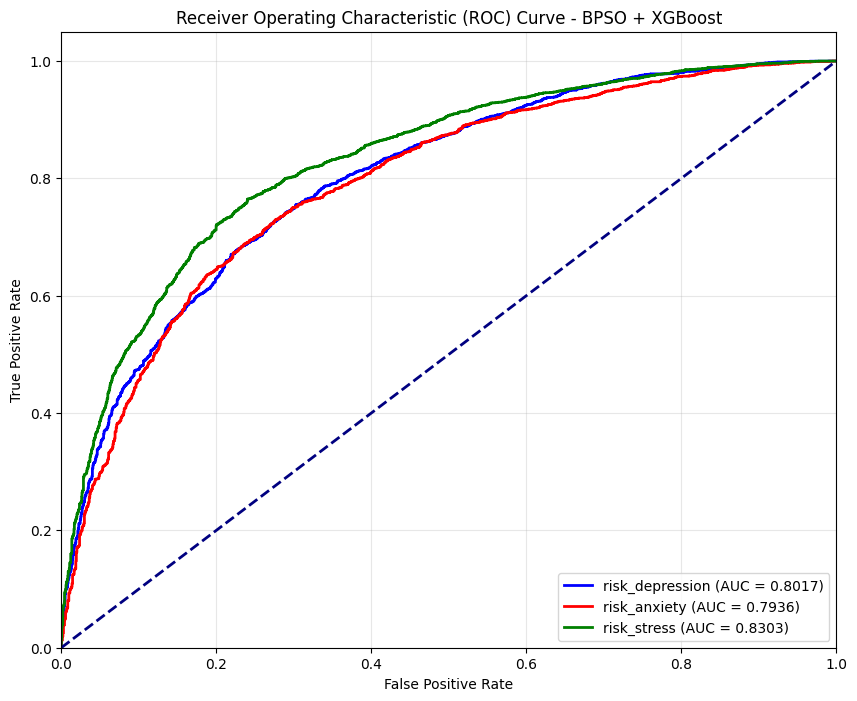

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# =============================================
# CEK 5: EVALUASI ROC-AUC
# =============================================
# Mengambil probabilitas prediksi dari ClassifierChain
n_samples = X_test_bpso.shape[0]
n_targets = len(target_cols)
y_pred_proba = np.zeros((n_samples, n_targets))

X_aug = X_test_bpso.copy()
for i, estimator in enumerate(final_chain.estimators_):
    proba = estimator.predict_proba(X_aug)[:, 1]
    y_pred_proba[:, i] = proba
    pred_label = (proba >= optimal_thresholds[i]).astype(int).reshape(-1, 1)
    X_aug = np.hstack([X_aug, pred_label])

print("=" * 55)
print("📈 ROC-AUC SCORE EVALUATION")
print("=" * 55)

roc_auc_scores = {}
for i, target_name in enumerate(target_cols):
    score = roc_auc_score(y_test[:, i], y_pred_proba[:, i])
    roc_auc_scores[target_name] = score
    print(f"ROC-AUC {target_name:<20}: {score:.4f}")

macro_roc_auc = np.mean(list(roc_auc_scores.values()))
print("-" * 55)
print(f"Macro Average ROC-AUC     : {macro_roc_auc:.4f}")
print("=" * 55)

# Visualisasi Kurva ROC
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, target_name in enumerate(target_cols):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"{target_name} (AUC = {roc_auc_scores[target_name]:.4f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - BPSO + XGBoost')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
